In [1]:
import numpy as np
import matplotlib.pyplot as plt
import timeit
from pathlib import Path

# Punto 1 - Muestreo de distribuciones de probabilidad

In [2]:
# Carpeta donde se guardarán los gráficos del TP.
GRAFICOS_DIR = Path("graficos")

# Creamos la carpeta si todavía no existe.
GRAFICOS_DIR.mkdir(exist_ok=True)

In [3]:
# Carpeta específica para los gráficos del punto 1.
PUNTO1_DIR = GRAFICOS_DIR / "punto1"
PUNTO1_DIR.mkdir(exist_ok=True)

In [4]:
def normal_12_uniforms(mu, sigma2):
    """
    Genera una muestra aproximada de una distribución normal N(mu, sigma2)
    sumando 12 muestras de una distribución uniforme.

    mu: media de la normal
    sigma2: varianza de la normal
    """

    # La consigna recibe la varianza, por lo que calculamos
    # el desvío estándar para escalar la muestra.
    sigma = np.sqrt(sigma2)

    # La suma de 12 uniformes U(0,1) tiene media 6 y varianza 1.
    # Restando 6 obtenemos una variable aproximadamente N(0,1).
    z = np.sum(np.random.uniform(0, 1, 12)) - 6

    # Escalamos y desplazamos para obtener N(mu, sigma2).
    return mu + sigma * z

In [5]:
def normal_rejection(mu, sigma2):
    """
    Genera una muestra de una distribución normal N(mu, sigma2)
    utilizando muestreo con rechazo.

    mu: media de la normal
    sigma2: varianza de la normal
    """

    sigma = np.sqrt(sigma2)

    while True:
        # Generamos dos muestras uniformes dentro del cuadrado [-1, 1] x [-1, 1].
        u1 = np.random.uniform(-1, 1)
        u2 = np.random.uniform(-1, 1)

        # Distancia cuadrada al origen.
        s = u1**2 + u2**2

        # Solo aceptamos puntos que estén dentro del círculo unitario.
        # También descartamos s = 0 porque aparecería una división por cero.
        if 0 < s < 1:
            z = u1 * np.sqrt(-2 * np.log(s) / s)

            return mu + sigma * z

In [6]:
def normal_box_muller(mu, sigma2):
    """
    Genera una muestra de una distribución normal N(mu, sigma2)
    utilizando la transformación de Box-Muller.

    mu: media de la normal
    sigma2: varianza de la normal
    """

    sigma = np.sqrt(sigma2)

    # Generamos las dos muestras uniformes requeridas por Box-Muller.
    u1 = np.random.uniform(0, 1)
    u2 = np.random.uniform(0, 1)

    # Evitamos log(0), ya que no está definido.
    while u2 == 0:
        u2 = np.random.uniform(0, 1)

    # Transformación de Box-Muller para obtener una N(0,1).
    z = np.cos(2 * np.pi * u1) * np.sqrt(-2 * np.log(u2))

    # Transformamos la normal estándar a N(mu, sigma2).
    return mu + sigma * z

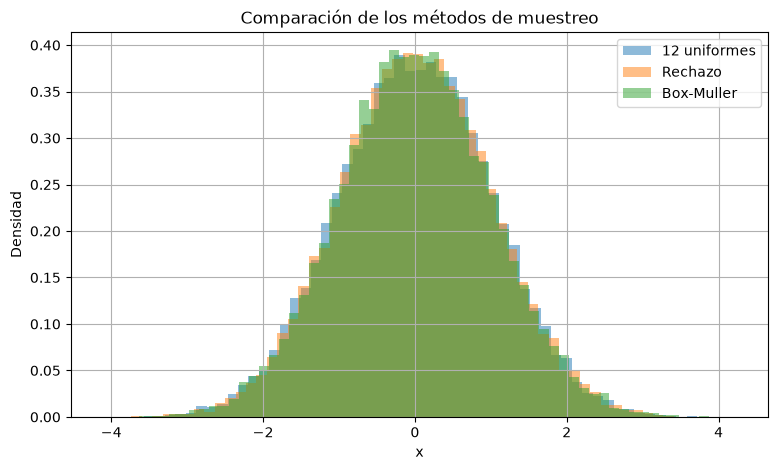

In [7]:
# Parámetros usados para probar los métodos.
mu = 0
sigma2 = 1

# Cantidad de muestras para visualizar las distribuciones.
N = 20000

samples_12 = np.array([
    normal_12_uniforms(mu, sigma2)
    for _ in range(N)
])

samples_rejection = np.array([
    normal_rejection(mu, sigma2)
    for _ in range(N)
])

samples_box_muller = np.array([
    normal_box_muller(mu, sigma2)
    for _ in range(N)
])


plt.figure(figsize=(9, 5))

plt.hist(
    samples_12,
    bins=60,
    density=True,
    alpha=0.5,
    label="12 uniformes"
)

plt.hist(
    samples_rejection,
    bins=60,
    density=True,
    alpha=0.5,
    label="Rechazo"
)

plt.hist(
    samples_box_muller,
    bins=60,
    density=True,
    alpha=0.5,
    label="Box-Muller"
)

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Comparación de los métodos de muestreo")
plt.legend()
plt.grid()

plt.savefig(
    PUNTO1_DIR / "distribuciones.jpg",
    dpi=300,
    bbox_inches="tight"
)

In [8]:
print("12 uniformes:")
print("Media:", np.mean(samples_12))
print("Varianza:", np.var(samples_12))

print("\nRechazo:")
print("Media:", np.mean(samples_rejection))
print("Varianza:", np.var(samples_rejection))

print("\nBox-Muller:")
print("Media:", np.mean(samples_box_muller))
print("Varianza:", np.var(samples_box_muller))

12 uniformes:
Media: 0.006683905173586551
Varianza: 1.0146458184999154

Rechazo:
Media: 0.010799041209950113
Varianza: 0.997848401052002

Box-Muller:
Media: 0.006147540964564425
Varianza: 0.9970887458467711


In [9]:
# Parámetros de la normal utilizada para comparar tiempos.
mu = 0
sigma2 = 1
sigma = np.sqrt(sigma2)

# Cantidad de muestras que generará cada método.
N = 100000


# Medimos el tiempo total de generación de N muestras.
time_12 = timeit.timeit(
    lambda: normal_12_uniforms(mu, sigma2),
    number=N
)

time_rejection = timeit.timeit(
    lambda: normal_rejection(mu, sigma2),
    number=N
)

time_box_muller = timeit.timeit(
    lambda: normal_box_muller(mu, sigma2),
    number=N
)

# numpy.random.normal recibe el desvío estándar y no la varianza.
time_numpy = timeit.timeit(
    lambda: np.random.normal(mu, sigma),
    number=N
)


print(f"12 uniformes:       {time_12:.4f} s")
print(f"Muestreo rechazo:   {time_rejection:.4f} s")
print(f"Box-Muller:         {time_box_muller:.4f} s")
print(f"numpy.random.normal:{time_numpy:.4f} s")

12 uniformes:       0.2676 s
Muestreo rechazo:   0.3338 s
Box-Muller:         0.2806 s
numpy.random.normal:0.0371 s


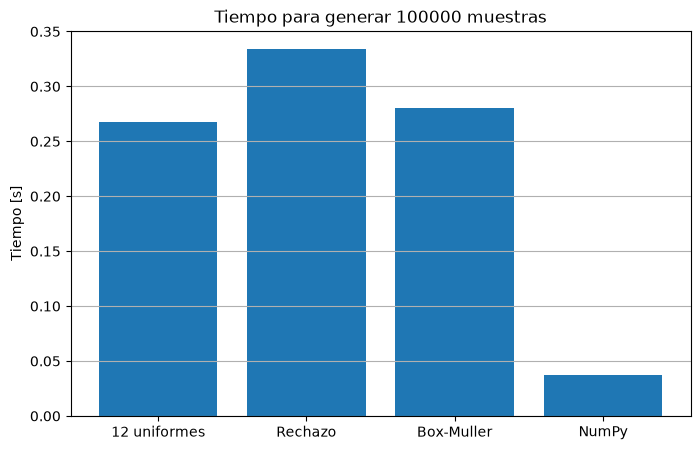

In [10]:
methods = [
    "12 uniformes",
    "Rechazo",
    "Box-Muller",
    "NumPy"
]

times = [
    time_12,
    time_rejection,
    time_box_muller,
    time_numpy
]


plt.figure(figsize=(8, 5))

plt.bar(methods, times)

plt.ylabel("Tiempo [s]")
plt.title(f"Tiempo para generar {N} muestras")
plt.grid(axis="y")

plt.savefig(
    PUNTO1_DIR / "tiempos.jpg",
    dpi=300,
    bbox_inches="tight"
)

### Comparación de tiempos

Para 100000 muestras, numpy.random.normal fue el método más rápido. Entre las funciones implementadas, Box-Muller tuvo el menor tiempo de ejecución, seguido por el método de las 12 uniformes, mientras que el muestreo con rechazo fue el más lento. Esto tiene sentido porque el método con rechazo puede necesitar generar más de una pareja de valores uniformes antes de aceptar una muestra.

## 2.1 Campos Potenciales Artificiales

Se implementaron las fuerzas atractiva y repulsiva en
`campos_potenciales.py`. La fuerza atractiva dirige al robot hacia
la meta y la fuerza repulsiva actúa cuando el robot se encuentra
a menos de una distancia `d_0` de un obstáculo.

![Resultado APF](graficos/punto2/apf_minimo_local.jpeg)

Un mínimo local ocurre cuando la fuerza atractiva hacia el objetivo y las fuerzas repulsivas de los obstáculos se compensan, haciendo que el robot quede detenido antes de llegar a la meta. En nuestra implementación esto ocurre, ya que el robot queda estancado antes de alcanzar el objetivo.

## 2.2 Algoritmo de Dijkstra

Se implementó la conectividad de 8 vecinos, considerando movimientos horizontales, verticales y diagonales dentro de los límites del mapa.

Para detectar obstáculos se utilizó un umbral de ocupación de 0.5. De esta forma, una celda se considera ocupada cuando su probabilidad de ocupación es mayor o igual al 50%. En ese caso, el costo de atravesarla se considera infinito.

Para las celdas que no son obstáculos, se agregó su probabilidad de ocupación al costo del movimiento. Así, entre caminos de longitud similar, el algoritmo tiende a elegir el que pasa por celdas con menor probabilidad de estar ocupadas.

El algoritmo encontró un camino libre de colisiones con un costo de 65.62.

![Resultado Dijkstra](graficos/punto2/dijkstra.jpeg)

A medida que aumenta el área a explorar, también aumenta la cantidad de nodos que Dijkstra puede tener que analizar, por lo que la búsqueda se vuelve más lenta. En un entorno abierto existen más celdas accesibles y el algoritmo puede expandirse en muchas direcciones. En cambio, los obstáculos pueden limitar las zonas alcanzables y reducir la cantidad de nodos explorados, aunque si generan muchos desvíos o caminos sin salida también pueden aumentar el trabajo necesario para encontrar el camino.

## 2.3 Algoritmo A*

Para que A* asegure encontrar un camino óptimo, la heurística debe ser **admisible**, es decir, nunca debe sobreestimar el costo real restante hasta el objetivo. Además, para una búsqueda sobre grafos como la implementada, es conveniente que sea **consistente**, de manera que para dos nodos vecinos se cumpla que la estimación desde un nodo no sea mayor que el costo de pasar al siguiente más la heurística de ese nodo.

Como heurística se utilizó la distancia euclídea entre la celda actual y el objetivo:

\[
h(n)=\sqrt{(x-x_g)^2+(y-y_g)^2}
\]

Esta distancia representa una estimación directa del costo restante hasta la meta.

La actualización de costos y predecesores utiliza la misma lógica implementada para Dijkstra: si llegar a un vecino a través del nodo actual produce un costo acumulado menor, se actualizan su costo y su predecesor.

Para analizar la influencia de la heurística, se realizaron pruebas multiplicándola por distintos factores:

| Factor de heurística | Costo del camino |
|---|---:|
| 1 × h | 65.62 |
| 2 × h | 68.26 |
| 5 × h | 72.12 |
| 10 × h | 86.07 |

![A* con h](graficos/punto2/Astar_h1.jpeg)

![A* con 2h](graficos/punto2/Astar_h2.jpeg)

![A* con 5h](graficos/punto2/Astar_h5.jpeg)

![A* con 10h](graficos/punto2/Astar_h10.jpeg)

Con un factor igual a 1, A* obtuvo un costo de 65.62, el mismo costo obtenido con Dijkstra, pero realizando una búsqueda más dirigida hacia el objetivo.

Al aumentar el peso de la heurística, el algoritmo prioriza cada vez más los nodos que parecen acercarse directamente a la meta, reduciendo la exploración de otras alternativas. Sin embargo, al multiplicar la heurística por factores mayores que 1 se pierde en general la propiedad de admisibilidad, por lo que ya no se garantiza encontrar el camino óptimo.

Esto se observa en los resultados obtenidos: el costo aumentó de 65.62 con h a 68.26 con 2h, 72.12 con 5h y 86.07 con 10h. Por lo tanto, aumentar el peso de la heurística genera una búsqueda más dirigida, pero a costa de obtener caminos de mayor costo.

## 2.4 Planificación de Cualquier Ángulo (Any-Angle): Theta*

Theta* evalúa dos alternativas al actualizar cada nodo: el camino clásico desde el nodo padre hacia el vecino y un posible camino directo desde el predecesor del padre, es decir, desde el “abuelo” hacia el vecino.

Si existe línea de visión directa entre el abuelo y el vecino, se compara el costo de ambas alternativas. Si el camino directo resulta más económico, el vecino pasa a tener como predecesor al abuelo, permitiendo así realizar saltos con ángulos que no están restringidos a la conectividad de la grilla.

Se compararon los resultados obtenidos con A* y Theta*:

| Algoritmo | Costo | Longitud real |
|---|---:|---:|
| A* | 65.62 | 63.46 |
| Theta* | 61.66 | 58.46 |

![Resultado Theta*](graficos/punto2/theta_star.jpeg)

Theta* obtuvo una longitud real de **58.46**, mientras que A* obtuvo **63.46**.

Esto ocurre porque A* construye el camino utilizando los movimientos permitidos por la conectividad de la grilla, por lo que queda restringido a movimientos horizontales, verticales y diagonales.

Theta*, en cambio, puede conectar directamente nodos que no son vecinos cuando existe línea de visión entre ellos. Esto permite eliminar nodos intermedios innecesarios y generar segmentos con ángulos arbitrarios, obteniendo una trayectoria más directa y, en este caso, más corta.

## 3.1 Path Planning

Se implementó el algoritmo A* sobre el mapa de ocupación recibido mediante ROS. El algoritmo utiliza conectividad de 8 vecinos y la distancia euclídea al objetivo como heurística.

El camino calculado se almacena como una lista de coordenadas de mapa y luego se convierte a coordenadas del mundo para publicarlo mediante un mensaje `nav_msgs/Path` en el tópico `/plan`.

![Path Planning en ROS](graficos/punto3/path_planning_ros.jpeg)

### ¿Es el camino calculado físicamente realizable?

No necesariamente. El algoritmo verifica que las celdas utilizadas por el camino estén libres según el mapa de ocupación, pero no tiene toda la información necesaria para asegurar que el robot pueda recorrer físicamente el camino.

Por ejemplo, no considera explícitamente las dimensiones o la huella del robot ni todas sus restricciones de movimiento. Por lo tanto, una celda puede considerarse libre para el planificador, pero eso no garantiza que exista espacio suficiente para que pase el robot completo.

### ¿Tiene en cuenta el algoritmo la orientación inicial del robot?

No. El estado utilizado por el algoritmo está definido únicamente por las coordenadas `(x, y)` de cada celda. La orientación inicial del robot no forma parte del estado considerado durante la planificación.

Por lo tanto, dos robots ubicados en la misma posición pero con distintas orientaciones iniciales obtendrían el mismo camino.

## 3.2 Path Following

Se implementó un controlador **Pure Pursuit** para que el robot siga el camino publicado en `/plan`. El algoritmo busca el punto más cercano de la trayectoria y selecciona un punto adelantado según `lookahead_distance`. A partir de la posición relativa de este punto respecto del robot, calcula la curvatura necesaria y publica las velocidades lineal y angular en `/cmd_vel`.

Se realizaron distintas pruebas variando los parámetros `lookahead_distance`, `target_speed` y `goal_tolerance`.

| Lookahead [m] | Velocidad [m/s] | Tolerancia [m] | Comportamiento observado |
|---:|---:|---:|---|
| 0.60 | 0.20 | 0.20 | El robot corta demasiado las curvas y termina chocando con una pared. |
| 0.25 | 0.10 | 0.20 | El seguimiento mejora considerablemente, aunque puede colisionar cuando el camino pasa muy cerca de una pared. |
| 0.15 | 0.10 | 0.20 | El controlador se vuelve demasiado reactivo, con desviaciones y correcciones fuertes. |
| 0.25 | 0.20 | 0.20 | Al aumentar la velocidad empeora el seguimiento y aumenta la desviación respecto del camino. |
| 0.30 | 0.08 | 0.25 | Se obtiene un seguimiento más suave y preciso. En una zona abierta el robot logró llegar al objetivo y detenerse correctamente. |

### Pruebas realizadas

**Lookahead grande (`0.60 m`):**

![Pure Pursuit - lookahead 0.60](graficos/punto3/pure_pursuit_lookahead_060.jpeg)

**Lookahead intermedio (`0.25 m`):**

![Pure Pursuit - lookahead 0.25](graficos/punto3/pure_pursuit_lookahead_025.jpeg)

**Lookahead pequeño (`0.15 m`):**

![Pure Pursuit - lookahead 0.15](graficos/punto3/pure_pursuit_lookahead_015.jpeg)

**Mayor velocidad (`0.20 m/s`):**

![Pure Pursuit - velocidad 0.20](graficos/punto3/pure_pursuit_speed_020.jpeg)

Finalmente se utilizó:

- `lookahead_distance = 0.30 m`
- `target_speed = 0.08 m/s`
- `goal_tolerance = 0.25 m`

En una trayectoria con suficiente espacio libre, el robot logró seguir el camino, alcanzar el objetivo y detenerse correctamente.

![Pure Pursuit - objetivo alcanzado](graficos/punto3/pure_pursuit_goal_reached.jpeg)

### 1. ¿Cómo afecta el lookahead distance al desempeño del robot?

El `lookahead_distance` determina qué tan adelantado sobre la trayectoria se encuentra el punto que utiliza Pure Pursuit para calcular el movimiento.

Cuando el lookahead es demasiado grande, el robot tiende a tomar atajos y cortar las curvas, alejándose de la trayectoria planificada. Esto se observó con `0.60 m`, donde el robot terminó chocando con una pared.

Cuando el lookahead es demasiado pequeño, el controlador se vuelve muy sensible a pequeños errores de posición y orientación. Con `0.15 m` se observaron correcciones más fuertes y un comportamiento más inestable.

Los valores intermedios, alrededor de `0.25-0.30 m`, produjeron un seguimiento más estable y cercano al camino.

### 2. ¿Llega el robot al objetivo? ¿En caso que falle, por qué?

Depende de la trayectoria. En la prueba final, realizada en una zona abierta, el robot logró llegar al objetivo y detenerse correctamente.

Sin embargo, en otras pruebas el camino calculado pasaba demasiado cerca de una pared. En esos casos el robot colisionaba y quedaba físicamente trabado, aunque la trayectoria teórica continuaba avanzando en RViz.

Esto ocurre porque el planificador trabaja sobre el mapa de ocupación y no considera completamente las dimensiones físicas del robot. Por lo tanto, un camino puede ser válido para un punto sobre la grilla pero no dejar espacio suficiente para que pase el robot completo.

Además, el controlador utiliza `/calc_odom`, una odometría calculada a partir del movimiento comandado. Cuando el robot queda trabado contra una pared, esta estimación puede continuar avanzando aunque el robot en Gazebo no se esté desplazando realmente. Por esta razón, el controlador puede llegar teóricamente al objetivo y publicar velocidad cero aunque el robot físico haya quedado detenido antes por una colisión.

### 3. ¿Qué fuentes de error se pueden observar?

Se observaron errores provenientes de distintas fuentes.

Por un lado, existen errores de **planeamiento**. El algoritmo de path planning no considera completamente el tamaño físico del robot ni mantiene necesariamente una distancia de seguridad respecto de los obstáculos. Esto puede generar caminos demasiado cercanos a las paredes.

También existen errores de **ejecución y control**. Un lookahead demasiado grande hace que el robot corte las curvas, mientras que uno demasiado pequeño produce correcciones más agresivas. Del mismo modo, una velocidad mayor dificulta que el controlador corrija la trayectoria a tiempo.

Finalmente, existe una fuente de error asociada a la **estimación de la posición**. Al utilizar la odometría calculada `/calc_odom`, la posición estimada puede continuar avanzando según los comandos enviados incluso cuando el robot real se encuentra bloqueado por una colisión.

Por lo tanto, el resultado final depende tanto de la calidad del camino planificado como del controlador utilizado para seguirlo y de la precisión de la estimación del estado del robot.

## Ejercicio 4

In [11]:
def differential_odometry_motion_model(x_prev, x_odom, alpha):
    """
    Genera una posible nueva pose del robot a partir del cambio de odometría,
    incorporando ruido en la traslación y en las rotaciones.

    Parámetros:
        x_prev : pose anterior [x, y, theta]
        x_odom : nueva pose medida por odometría [x, y, theta]
        alpha  : parámetros de ruido [alpha1, alpha2, alpha3, alpha4]

    Retorna:
        Nueva pose [x, y, theta] afectada por ruido.
    """

    x_prev_pos, y_prev_pos, theta_prev = x_prev
    x_odom_pos, y_odom_pos, theta_odom = x_odom

    alpha1, alpha2, alpha3, alpha4 = alpha

    # Cambio medido por la odometría.
    dx = x_odom_pos - x_prev_pos
    dy = y_odom_pos - y_prev_pos

    # Primera rotación necesaria para orientarse en la dirección
    # del movimiento medido.
    delta_rot1 = np.arctan2(dy, dx) - theta_prev

    # Traslación medida.
    delta_trans = np.sqrt(dx**2 + dy**2)

    # Segunda rotación necesaria para alcanzar la orientación final.
    delta_rot2 = theta_odom - theta_prev - delta_rot1

    # -------------------------------------------------------------
    # Agregamos ruido a cada componente del movimiento.
    # Las varianzas dependen de cuánto se trasladó y rotó el robot.
    # -------------------------------------------------------------

    var_rot1 = (
        alpha1 * delta_rot1**2
        + alpha2 * delta_trans**2
    )

    var_trans = (
        alpha3 * delta_trans**2
        + alpha4 * delta_rot1**2
        + alpha4 * delta_rot2**2
    )

    var_rot2 = (
        alpha1 * delta_rot2**2
        + alpha2 * delta_trans**2
    )

    noisy_rot1 = delta_rot1 - normal_box_muller(0, var_rot1)
    noisy_trans = delta_trans - normal_box_muller(0, var_trans)
    noisy_rot2 = delta_rot2 - normal_box_muller(0, var_rot2)

    # Pose resultante aplicando el movimiento ruidoso.
    x_new = (
        x_prev_pos
        + noisy_trans * np.cos(theta_prev + noisy_rot1)
    )

    y_new = (
        y_prev_pos
        + noisy_trans * np.sin(theta_prev + noisy_rot1)
    )

    theta_new = (
        theta_prev
        + noisy_rot1
        + noisy_rot2
    )

    return np.array([x_new, y_new, theta_new])

In [12]:
x_prev = np.array([0.0, 0.0, 0.785])
x_odom = np.array([0.01, 0.01, 0.765])

alpha = np.array([
    20.0,
    20.0,
    0.01,
    0.01
])

N = 5000

samples_differential = np.array([
    differential_odometry_motion_model(
        x_prev,
        x_odom,
        alpha
    )
    for _ in range(N)
])

samples_differential.shape

(5000, 3)

In [13]:
PUNTO4_DIR = GRAFICOS_DIR / "punto4"
PUNTO4_DIR.mkdir(exist_ok=True)

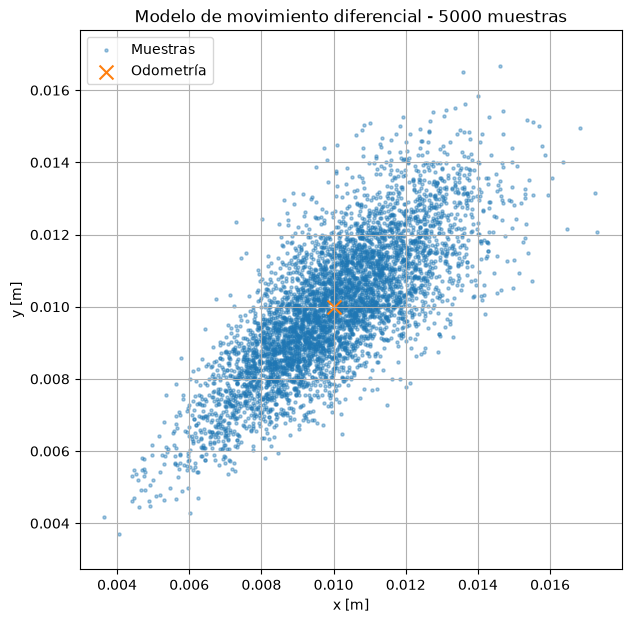

In [14]:
plt.figure(figsize=(7, 7))

plt.scatter(
    samples_differential[:, 0],
    samples_differential[:, 1],
    s=5,
    alpha=0.4,
    label="Muestras"
)

# Pose indicada por la odometría.
plt.scatter(
    x_odom[0],
    x_odom[1],
    marker="x",
    s=100,
    label="Odometría"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Modelo de movimiento diferencial - 5000 muestras")

plt.axis("equal")
plt.grid()
plt.legend()

plt.savefig(
    PUNTO4_DIR / "movimiento_diferencial.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.1 Movimiento Diferencial

Se implementó el modelo de movimiento basado en odometría diferencial, agregando ruido a las dos componentes de rotación y a la traslación mediante muestras normales generadas con el método de Box-Muller implementado en el punto 1.

Se generaron 5000 muestras utilizando:

$$
x_{t-1} =
\begin{pmatrix}
0 \\
0 \\
0.785
\end{pmatrix},
\qquad
x_t =
\begin{pmatrix}
0.01 \\
0.01 \\
0.765
\end{pmatrix},
\qquad
\alpha =
\begin{pmatrix}
20 \\
20 \\
0.01 \\
0.01
\end{pmatrix}
$$

La nube de muestras se concentra alrededor de la posición indicada por la odometría y presenta una dispersión orientada en la dirección del movimiento, como consecuencia del ruido introducido en la traslación y las rotaciones.

<div align="center">
    <img src="graficos/punto4/movimiento_diferencial.jpeg" width="600">
</div>

In [15]:
def holonomic_odometry_motion_model(x_prev, x_odom, alpha):
    """
    Genera una posible nueva pose para un robot holonómico
    a partir de una medición de odometría con ruido.

    Parámetros:
        x_prev : pose anterior [x, y, theta]
        x_odom : nueva pose medida por odometría [x, y, theta]
        alpha  : parámetros de ruido [alpha1, ..., alpha6]

    Retorna:
        Nueva pose [x, y, theta] afectada por ruido.
    """

    x_prev_pos, y_prev_pos, theta_prev = x_prev
    x_odom_pos, y_odom_pos, theta_odom = x_odom

    alpha1, alpha2, alpha3, alpha4, alpha5, alpha6 = alpha

    # Diferencia de posición medida por la odometría.
    dx = x_odom_pos - x_prev_pos
    dy = y_odom_pos - y_prev_pos

    # -------------------------------------------------------------
    # Expresar el movimiento en el sistema de referencia del robot.
    # Un robot holonómico puede desplazarse tanto longitudinalmente
    # como lateralmente.
    # -------------------------------------------------------------
    delta_trans_x = (
        dx * np.cos(theta_prev)
        + dy * np.sin(theta_prev)
    )

    delta_trans_y = (
        -dx * np.sin(theta_prev)
        + dy * np.cos(theta_prev)
    )

    delta_rot = theta_odom - theta_prev

    # -------------------------------------------------------------
    # Varianzas del ruido.
    # Se utilizan directamente como varianza porque nuestras funciones
    # del punto 1 reciben sigma^2.
    # -------------------------------------------------------------
    var_trans_x = (
        alpha1 * delta_trans_x**2
        + alpha2 * delta_trans_y**2
        + alpha3 * delta_rot**2
    )

    var_trans_y = (
        alpha2 * delta_trans_x**2
        + alpha1 * delta_trans_y**2
        + alpha3 * delta_rot**2
    )

    var_rot = (
        alpha4 * delta_trans_x**2
        + alpha5 * delta_trans_y**2
        + alpha6 * delta_rot**2
    )

    # Agregar ruido normalmente distribuido.
    noisy_trans_x = (
        delta_trans_x
        - normal_box_muller(0, var_trans_x)
    )

    noisy_trans_y = (
        delta_trans_y
        - normal_box_muller(0, var_trans_y)
    )

    noisy_rot = (
        delta_rot
        - normal_box_muller(0, var_rot)
    )

    # -------------------------------------------------------------
    # Volver del sistema local del robot al sistema global.
    # -------------------------------------------------------------
    x_new = (
        x_prev_pos
        + noisy_trans_x * np.cos(theta_prev)
        - noisy_trans_y * np.sin(theta_prev)
    )

    y_new = (
        y_prev_pos
        + noisy_trans_x * np.sin(theta_prev)
        + noisy_trans_y * np.cos(theta_prev)
    )

    theta_new = theta_prev + noisy_rot

    return np.array([x_new, y_new, theta_new])

In [16]:
x_prev_holo = np.array([0.0, 0.0, 0.785])
x_odom_holo = np.array([0.01, 0.01, 0.765])

alpha_holo = np.array([
    0.2300,
    0.0012,
    0.0044,
    0.4300,
    0.0330,
    0.6383
])

N = 5000

samples_holonomic = np.array([
    holonomic_odometry_motion_model(
        x_prev_holo,
        x_odom_holo,
        alpha_holo
    )
    for _ in range(N)
])

samples_holonomic.shape

(5000, 3)

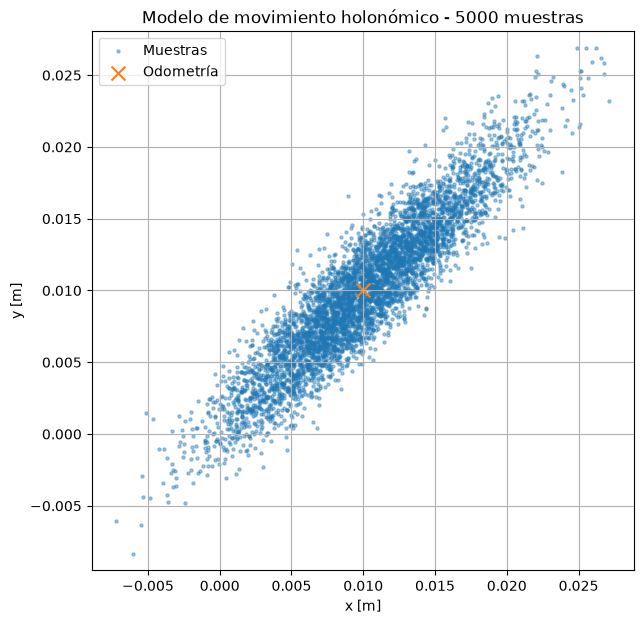

In [17]:
plt.figure(figsize=(7, 7))

plt.scatter(
    samples_holonomic[:, 0],
    samples_holonomic[:, 1],
    s=5,
    alpha=0.4,
    label="Muestras"
)

plt.scatter(
    x_odom_holo[0],
    x_odom_holo[1],
    marker="x",
    s=100,
    label="Odometría"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Modelo de movimiento holonómico - 5000 muestras")

plt.axis("equal")
plt.grid()
plt.legend()

plt.savefig(
    PUNTO4_DIR / "movimiento_holonomico.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.2 Movimiento Holonómico

Se implementó un modelo de movimiento basado en odometría holonómica. A diferencia del modelo diferencial, el movimiento se descompone en una componente longitudinal, una componente lateral y una rotación, agregando ruido normalmente distribuido a cada una de ellas.

Se generaron 5000 muestras utilizando:

$$
x_{t-1} =
\begin{pmatrix}
0 \\
0 \\
0.785
\end{pmatrix},
\qquad
x_t =
\begin{pmatrix}
0.01 \\
0.01 \\
0.765
\end{pmatrix},
\qquad
\alpha =
\begin{pmatrix}
0.2300 \\
0.0012 \\
0.0044 \\
0.4300 \\
0.0330 \\
0.6383
\end{pmatrix}
$$

La distribución se concentra alrededor de la posición indicada por la odometría, pero presenta una dispersión mayor que la obtenida con el modelo diferencial, debido a la incertidumbre asociada tanto al movimiento longitudinal como al movimiento lateral.

<div align="center">
    <img src="graficos/punto4/movimiento_holonomico.jpeg" width="600">
</div>

## 4.3 Evaluación de modelos

### 1. ¿Cómo se diferencian las morfologías de las distribuciones?

En ambos modelos las muestras se distribuyen alrededor de la posición indicada por la odometría y se encuentran orientadas aproximadamente en la dirección del movimiento.

Sin embargo, la distribución del modelo diferencial es más compacta, mientras que en el modelo holonómico se observa una distribución más alargada y con mayor dispersión.

Esto se debe a que el robot diferencial tiene mayores restricciones cinemáticas sobre sus posibles movimientos, mientras que el robot holonómico puede desplazarse tanto longitudinal como lateralmente, incorporando incertidumbre en ambas direcciones.

### 2. ¿Puedo utilizar la distribución de robots holonómicos para un robot diferencial? ¿Cuál sería la desventaja?

No sería un modelo adecuado. Un modelo holonómico permite desplazamientos laterales que un robot diferencial no puede realizar directamente.

Utilizar esta distribución para un robot diferencial asignaría probabilidad a movimientos que físicamente no son posibles para ese robot y produciría una estimación de incertidumbre mayor y menos representativa de su movimiento real.

### 3. ¿Puedo utilizar la distribución de robots diferenciales para un robot holonómico?

Tampoco sería adecuado. El modelo diferencial no representa correctamente los desplazamientos laterales que un robot holonómico sí puede realizar.

Por lo tanto, se estaría subestimando la incertidumbre del movimiento y podrían quedar fuera de la distribución movimientos que son físicamente posibles para el robot holonómico.

In [18]:
x_prev_slow = np.array([0.0, 0.0, 0.785])

x_odom_slow = np.array([
    0.2300,
    0.1576,
    0.3850
])

N = 5000

In [19]:
samples_differential_slow = np.array([
    differential_odometry_motion_model(
        x_prev_slow,
        x_odom_slow,
        alpha
    )
    for _ in range(N)
])

samples_holonomic_slow = np.array([
    holonomic_odometry_motion_model(
        x_prev_slow,
        x_odom_slow,
        alpha_holo
    )
    for _ in range(N)
])

print(samples_differential_slow.shape)
print(samples_holonomic_slow.shape)

(5000, 3)
(5000, 3)


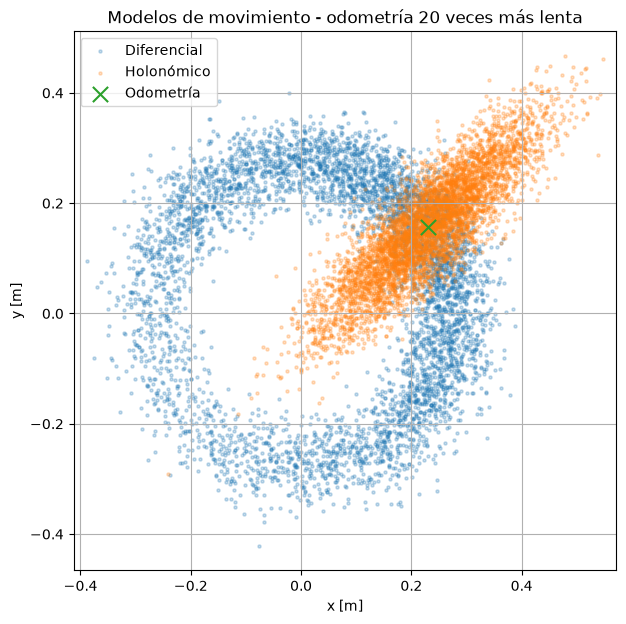

In [20]:
plt.figure(figsize=(7, 7))

plt.scatter(
    samples_differential_slow[:, 0],
    samples_differential_slow[:, 1],
    s=5,
    alpha=0.25,
    label="Diferencial"
)

plt.scatter(
    samples_holonomic_slow[:, 0],
    samples_holonomic_slow[:, 1],
    s=5,
    alpha=0.25,
    label="Holonómico"
)

plt.scatter(
    x_odom_slow[0],
    x_odom_slow[1],
    marker="x",
    s=120,
    label="Odometría"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Modelos de movimiento - odometría 20 veces más lenta")

plt.axis("equal")
plt.grid()
plt.legend()

plt.savefig(
    PUNTO4_DIR / "odometria_20x_lenta.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4. Efecto de una odometría 20 veces más lenta

Se mantuvieron los mismos parámetros de ruido \(\alpha\), pero se evaluaron ambos modelos suponiendo una odometría 20 veces más lenta. En este caso se utilizó:

$$
x_t =
\begin{pmatrix}
0.2300 \\
0.1576 \\
0.3850
\end{pmatrix}
$$

El resultado muestra un aumento muy importante de la dispersión para ambos modelos.

<div align="center">
    <img src="graficos/punto4/odometria_20x_lenta.jpeg" width="600">
</div>

Esto ocurre porque los parámetros \(\alpha\) fueron calibrados para una determinada frecuencia de medición. Al disminuir la frecuencia de la odometría, cada actualización acumula un desplazamiento y una rotación mayores. Como las varianzas del modelo dependen de la magnitud de estos movimientos, el ruido introducido en cada actualización también aumenta.

En consecuencia, mantener los mismos valores de \(\alpha\) cuando la odometría es 20 veces más lenta produce distribuciones mucho más dispersas y una estimación de movimiento con mayor incertidumbre.

Además, se observa nuevamente una diferencia entre ambos modelos: el modelo diferencial presenta una distribución más curva y extendida, mientras que el modelo holonómico genera una distribución más alargada en la dirección general del movimiento.

In [22]:
PUNTO5_DIR = GRAFICOS_DIR / "punto5"
PUNTO5_DIR.mkdir(exist_ok=True)

In [23]:
def motion_update(bel, command):
    """
    Actualiza el belief según un comando de movimiento.

    command:
        "forward"  -> avanzar un paso
        "backward" -> retroceder un paso
    """

    n = len(bel)
    new_bel = np.zeros(n)

    for i, p in enumerate(bel):

        if command == "forward":

            # Última celda: no puede avanzar.
            if i == n - 1:
                new_bel[i] += p

            # Penúltima celda:
            # 25% se queda y 75% termina en la última.
            elif i == n - 2:
                new_bel[i] += 0.25 * p
                new_bel[i + 1] += 0.75 * p

            # Caso general.
            else:
                new_bel[i] += 0.25 * p
                new_bel[i + 1] += 0.50 * p
                new_bel[i + 2] += 0.25 * p

        elif command == "backward":

            # Primera celda: no puede retroceder.
            if i == 0:
                new_bel[i] += p

            # Segunda celda:
            # 25% se queda y 75% termina en la primera.
            elif i == 1:
                new_bel[i] += 0.25 * p
                new_bel[i - 1] += 0.75 * p

            # Caso general.
            else:
                new_bel[i] += 0.25 * p
                new_bel[i - 1] += 0.50 * p
                new_bel[i - 2] += 0.25 * p

        else:
            raise ValueError("El comando debe ser 'forward' o 'backward'.")

    return new_bel

In [24]:
bel_initial = np.hstack((
    np.zeros(10),
    1,
    np.zeros(9)
))

bel_9_3 = bel_initial.copy()

# 9 comandos de avanzar.
for _ in range(9):
    bel_9_3 = motion_update(bel_9_3, "forward")

# 3 comandos de retroceder.
for _ in range(3):
    bel_9_3 = motion_update(bel_9_3, "backward")

print("Suma del belief:", bel_9_3.sum())
print("Celda más probable:", np.argmax(bel_9_3))
print("Probabilidad:", bel_9_3.max())

Suma del belief: 1.0
Celda más probable: 16
Probabilidad: 0.2368401288986206


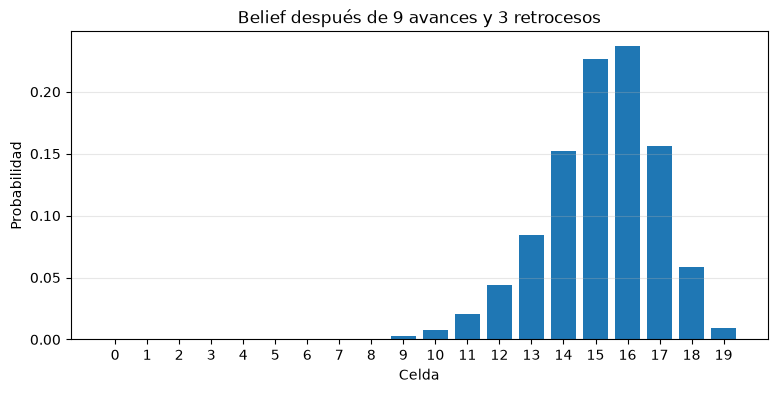

In [25]:
cells = np.arange(20)

plt.figure(figsize=(9, 4))

plt.bar(cells, bel_9_3)

plt.xlabel("Celda")
plt.ylabel("Probabilidad")
plt.title("Belief después de 9 avances y 3 retrocesos")

plt.xticks(cells)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    PUNTO5_DIR / "belief_9_avances_3_retrocesos.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

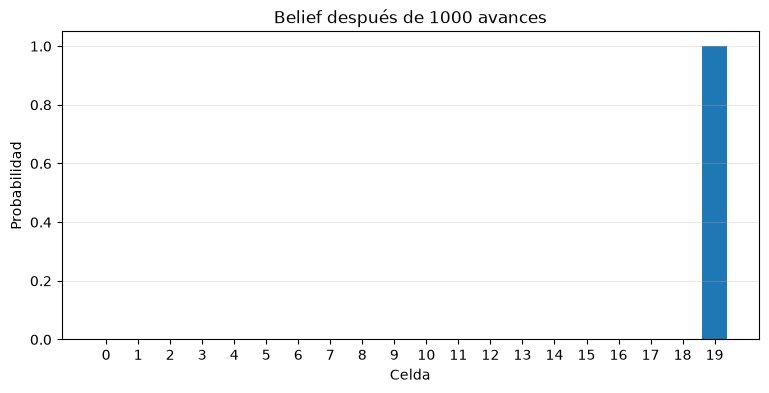

In [26]:
bel_1000_forward = bel_initial.copy()

for _ in range(1000):
    bel_1000_forward = motion_update(
        bel_1000_forward,
        "forward"
    )

plt.figure(figsize=(9, 4))

plt.bar(cells, bel_1000_forward)

plt.xlabel("Celda")
plt.ylabel("Probabilidad")
plt.title("Belief después de 1000 avances")

plt.xticks(cells)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    PUNTO5_DIR / "belief_1000_avances.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

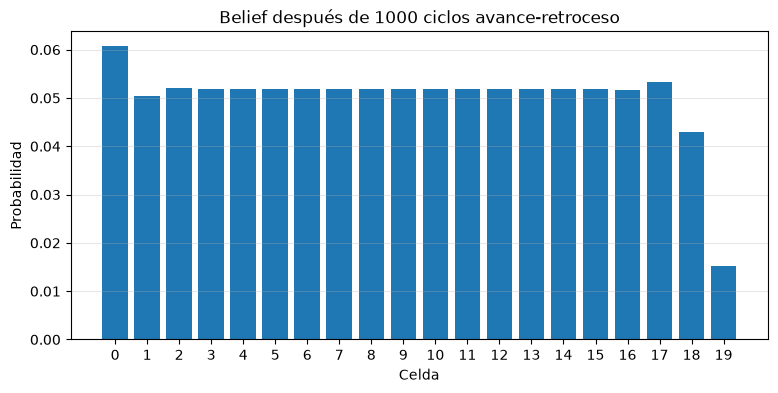

In [27]:
bel_1000_cycles = bel_initial.copy()

for _ in range(1000):
    bel_1000_cycles = motion_update(
        bel_1000_cycles,
        "forward"
    )

    bel_1000_cycles = motion_update(
        bel_1000_cycles,
        "backward"
    )

plt.figure(figsize=(9, 4))

plt.bar(cells, bel_1000_cycles)

plt.xlabel("Celda")
plt.ylabel("Probabilidad")
plt.title("Belief después de 1000 ciclos avance-retroceso")

plt.xticks(cells)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    PUNTO5_DIR / "belief_1000_avance_retroceso.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Filtro Discreto - Bayes

Se implementó un filtro discreto para estimar la posición de un robot en un mundo unidimensional de 20 celdas. El modelo de movimiento es probabilístico, por lo que cada comando distribuye la probabilidad entre distintas posiciones posibles.

El belief inicial concentra toda la probabilidad en la celda 10.

## 5.1 Nueve avances y tres retrocesos

Después de ejecutar 9 comandos de avance y 3 comandos de retroceso, la probabilidad queda distribuida entre varias celdas debido a la incertidumbre de cada movimiento.

La celda más probable es la 16, aunque existe una probabilidad significativa de que el robot se encuentre en posiciones cercanas.

<div align="center">
    <img src="graficos/punto5/belief_9_avances_3_retrocesos.jpeg" width="650">
</div>

## 5.2 Mil pasos de avance

Después de ejecutar 1000 comandos de avance, toda la probabilidad termina concentrándose en la celda 19.

Esto sucede porque el comando de avance nunca puede mover al robot hacia atrás. Por lo tanto, tarde o temprano el robot alcanza la última celda y, una vez allí, permanece en ella con probabilidad 1. La última celda funciona como un estado absorbente.

<div align="center">
    <img src="graficos/punto5/belief_1000_avances.jpeg" width="650">
</div>

## 5.3 Mil ciclos de avance y retroceso

Al repetir 1000 veces un comando de avance seguido de uno de retroceso, la distribución deja de estar concentrada alrededor de la posición inicial y se extiende por prácticamente todo el mundo.

Esto ocurre porque un avance seguido de un retroceso no garantiza volver a la misma celda. Cada comando puede producir un desplazamiento de 0, 1 o 2 celdas, por lo que la incertidumbre se acumula con cada ciclo.

Después de muchas iteraciones, el belief converge hacia una distribución aproximadamente estacionaria. En las celdas interiores las probabilidades son muy similares, mientras que cerca de los bordes aparecen diferencias debido a que las reglas de movimiento cambian al no poder salir del mundo.

<div align="center">
    <img src="graficos/punto5/belief_1000_avance_retroceso.jpeg" width="650">
</div>